### Загружаем данные

In [1]:
import numpy as np 
import pandas as pd 
import geopy.distance
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from folium.plugins import HeatMap
from sklearn.pipeline import make_pipeline

In [2]:
df = pd.read_csv("input_data.csv", sep = ';')

In [3]:
spb_df = df[df['id_region'] == 78]
spb_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 765872 entries, 15 to 11358128
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           765872 non-null  object 
 1   price          765872 non-null  int64  
 2   level          765872 non-null  int64  
 3   levels         765872 non-null  int64  
 4   rooms          765872 non-null  int64  
 5   area           765872 non-null  float64
 6   kitchen_area   765872 non-null  float64
 7   geo_lat        765872 non-null  float64
 8   geo_lon        765872 non-null  float64
 9   building_type  765872 non-null  int64  
 10  object_type    765872 non-null  int64  
 11  postal_code    723559 non-null  float64
 12  street_id      596776 non-null  float64
 13  id_region      765872 non-null  int64  
 14  house_id       667757 non-null  float64
dtypes: float64(7), int64(7), object(1)
memory usage: 93.5+ MB


In [4]:
spb_df.drop(columns=['postal_code', 'street_id', 'house_id', 'id_region'], inplace=True)

/tmp/ipykernel_30399/312713919.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spb_df.drop(columns=['postal_code', 'street_id', 'house_id', 'id_region'], inplace=True)


In [5]:
spb_df['price_per_metr'] = spb_df.price/spb_df.area

/tmp/ipykernel_30399/1708867088.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spb_df['price_per_metr'] = spb_df.price/spb_df.area


In [6]:
spb_df.nunique()

date                 365
price             140193
level                 36
levels                42
rooms                 10
area               10340
kitchen_area        3064
geo_lat            23762
geo_lon            23237
building_type          7
object_type            2
price_per_metr    264478
dtype: int64

In [7]:
spb_df.drop_duplicates(inplace = True)

/tmp/ipykernel_30399/2453167429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spb_df.drop_duplicates(inplace = True)


In [8]:
spb_df['date'] = spb_df['date'].astype('datetime64[ns]')

/tmp/ipykernel_30399/1415149795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spb_df['date'] = spb_df['date'].astype('datetime64[ns]')


<AxesSubplot:>

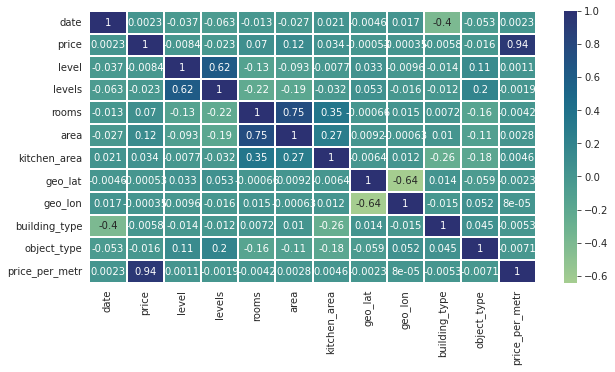

In [9]:
corr = spb_df.corr()
plt.figure(figsize=(10,5))
sns.heatmap(corr, cmap='crest', linewidth=0.3, annot=True)

In [10]:
import webbrowser

m = folium.Map(location=[spb_df["geo_lat"].mean(), spb_df["geo_lon"].mean()], zoom_start=10, control_scale=False)
map_values = spb_df[["geo_lat", "geo_lon", "price"]]
data_heat = map_values.values.tolist()
hm = HeatMap(data_heat, min_opacity=0.05, max_opacity=0.9, radius=25).add_to(m)

def auto_open(path):
    html_page = f'{path}'
    m.save(html_page)
    new = 2
    webbrowser.open(html_page, new=new)

auto_open("first.html")

In [11]:
Q1 = spb_df.price.quantile(0.25)
Q3 = spb_df.price.quantile(0.75)
IQR = Q3 - Q1
spb_df = spb_df[(spb_df.price > (Q1 - 1.5*IQR)) & (spb_df.price < (Q3 + 1.5*IQR))]

Q1 = spb_df.area.quantile(0.25)
Q3 = spb_df.area.quantile(0.75)
IQR = Q3 - Q1
spb_df = spb_df[(spb_df.area > (Q1 - 1.5*IQR)) & (spb_df.area < (Q3 + 1.5*IQR))]

Q1 = spb_df.kitchen_area.quantile(0.25)
Q3 = spb_df.kitchen_area.quantile(0.75)
IQR = Q3 - Q1
spb_df = spb_df[(spb_df.kitchen_area > (Q1 - 1.5*IQR)) & (spb_df.kitchen_area < (Q3 + 1.5*IQR))]

Q1 = spb_df.price_per_metr.quantile(0.25)
Q3 = spb_df.price_per_metr.quantile(0.75)
IQR = Q3 - Q1
spb_df = spb_df[(spb_df.price_per_metr > (Q1 - 1.5*IQR)) & (spb_df.price_per_metr < (Q3 + 1.5*IQR))]

for i in spb_df.columns[spb_df.dtypes != 'datetime64[ns]']:  
    if i != 'rooms':
        spb_df = spb_df[spb_df[i] >= 0]

In [12]:
saint_pet_centre = (59.938996, 30.315482)
sp = np.concatenate([spb_df.geo_lat.values.reshape(-1,1), spb_df.geo_lon.values.reshape(-1,1)], axis = 1)
dist_spb = list(map(lambda x: geopy.distance.geodesic(x, saint_pet_centre).km, sp))
spb_df['distance_from_centre'] = dist_spb
spb_df = spb_df[spb_df.distance_from_centre < 50]

In [13]:
m = folium.Map(location=[spb_df["geo_lat"].mean(), spb_df["geo_lon"].mean()], zoom_start=10, control_scale=False)
map_values = spb_df[["geo_lat", "geo_lon", "price"]]
data_heat = map_values.values.tolist()
hm = HeatMap(data_heat, min_opacity=0.05, max_opacity=0.9, radius=25).add_to(m)
auto_open("second.html")

In [14]:
spb_df = spb_df.drop(columns = ['date', 'geo_lat', 'geo_lon'])
spb_df.head()

,price,level,levels,rooms,area,kitchen_area,building_type,object_type,price_per_metr,distance_from_centre
15,8865000,10,13,2,66.70,14.60,4,2,132908.545727,11.167133
151,8865000,11,13,2,66.70,14.60,4,2,132908.545727,11.167133
221,3965000,20,23,1,30.50,13.00,0,2,130000.000000,12.990314
231,7408788,17,17,1,37.11,12.92,1,2,199643.977365,5.692645
424,12624923,13,15,2,63.18,22.00,0,2,199824.675530,19.328946


In [15]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
spb_df.describe()

,price,level,levels,rooms,area,kitchen_area,building_type,object_type,price_per_metr,distance_from_centre
count,567694.000,567694.000,567694.000,567694.000,567694.000,567694.000,567694.000,567694.000,567694.000,567694.000
mean,7786980.748,7.666,14.465,1.333,47.229,9.199,0.435,0.830,166919.472,10.580
std,3451209.063,5.760,7.098,1.256,18.310,6.168,1.081,0.985,39510.362,6.860
min,120000.000,0.000,0.000,-1.000,1.500,0.000,0.000,0.000,53658.537,0.019
25%,5277500.000,3.000,9.000,1.000,33.580,5.400,0.000,0.000,137820.627,6.190
50%,6949000.000,6.000,13.000,1.000,43.000,9.600,0.000,0.000,162370.062,10.268
75%,9500000.000,11.000,21.000,2.000,59.127,13.300,0.000,2.000,191457.041,13.571
max,20415490.000,35.000,45.000,9.000,99.410,32.150,6.000,2.000,280645.161,48.066


Text(0.0, 1.0, 'Распределение расстояния от центра')

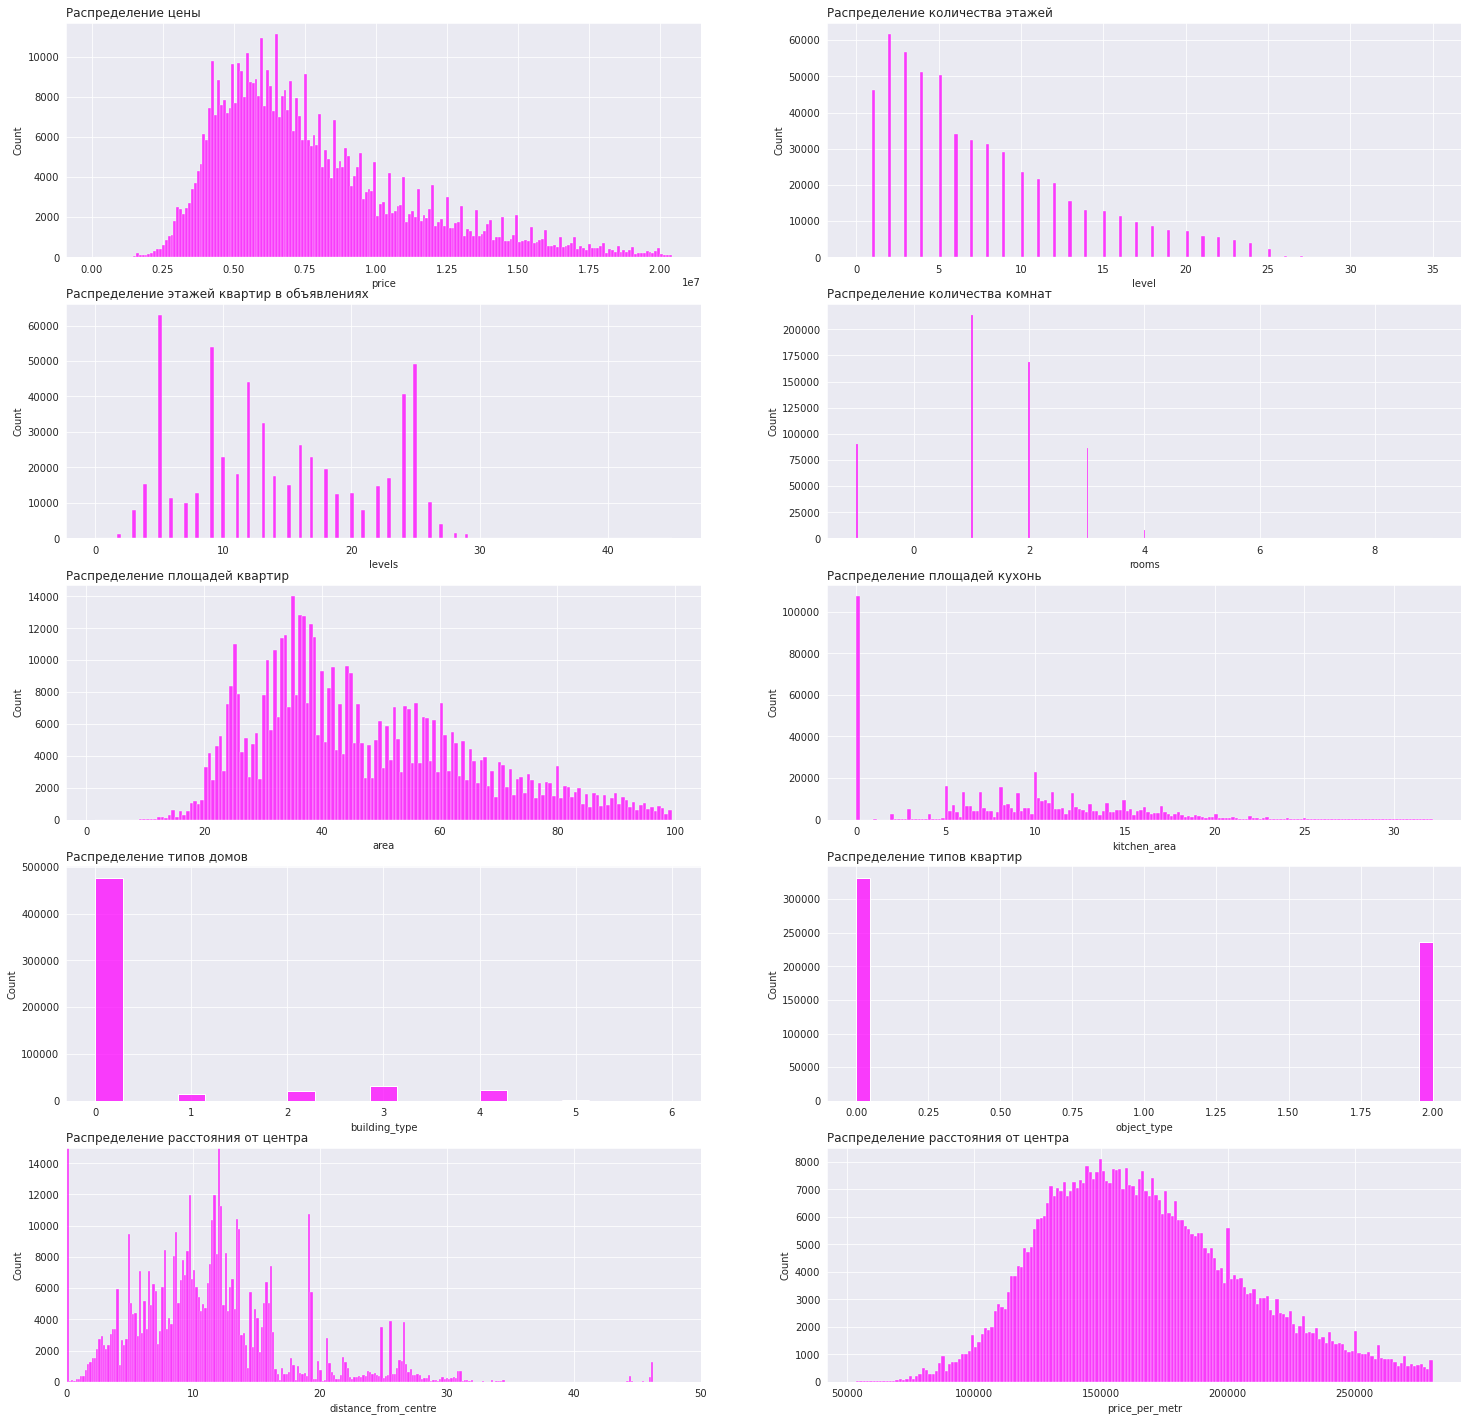

In [16]:
fig, axes = plt.subplots(5, 2, figsize = (25, 25))
sns.set()

sns.histplot(data = spb_df.price, ax = axes[0, 0], color=(1, 0, 1, 1))
axes[0, 0].set_title('Распределение цены', loc = 'left')

sns.histplot(data = spb_df.level, ax = axes[0, 1], color=(1, 0, 1, 1))
axes[0, 1].set_title('Распределение количества этажей', loc = 'left')

sns.histplot(data = spb_df.levels, ax = axes[1, 0], color=(1, 0, 1, 1))
axes[1, 0].set_title('Распределение этажей квартир в объявлениях', loc = 'left')

sns.histplot(data = spb_df.rooms, ax = axes[1, 1], color=(1, 0, 1, 1))
axes[1, 1].set_title('Распределение количества комнат', loc = 'left')

sns.histplot(data = spb_df.area, ax = axes[2, 0], color=(1, 0, 1, 1))
axes[2, 0].set_title('Распределение площадей квартир', loc = 'left')
axes[4, 0].set_xlim([0, 200])

sns.histplot(data = spb_df.kitchen_area, ax = axes[2, 1], color=(1, 0, 1, 1))
axes[2, 1].set_title('Распределение площадей кухонь', loc = 'left')
axes[4, 0].set_xlim([0, 40])

sns.histplot(data = spb_df.building_type, ax = axes[3, 0], color=(1, 0, 1, 1))
axes[3, 0].set_title('Распределение типов домов', loc = 'left')

sns.histplot(data = spb_df.object_type, ax = axes[3, 1], color=(1, 0, 1, 1))
axes[3, 1].set_title('Распределение типов квартир', loc = 'left')

sns.histplot(data = spb_df.distance_from_centre, ax = axes[4, 0], color=(1, 0, 1, 1))
axes[4, 0].set_title('Распределение расстояния от центра', loc = 'left')
axes[4, 0].set_xlim([0, 50])
axes[4, 0].set_ylim([0, 15000])

sns.histplot(data = spb_df.price_per_metr, ax = axes[4, 1], color=(1, 0, 1, 1))
axes[4, 1].set_title('Распределение расстояния от центра', loc = 'left')

<AxesSubplot:xlabel='price_per_metr', ylabel='price'>

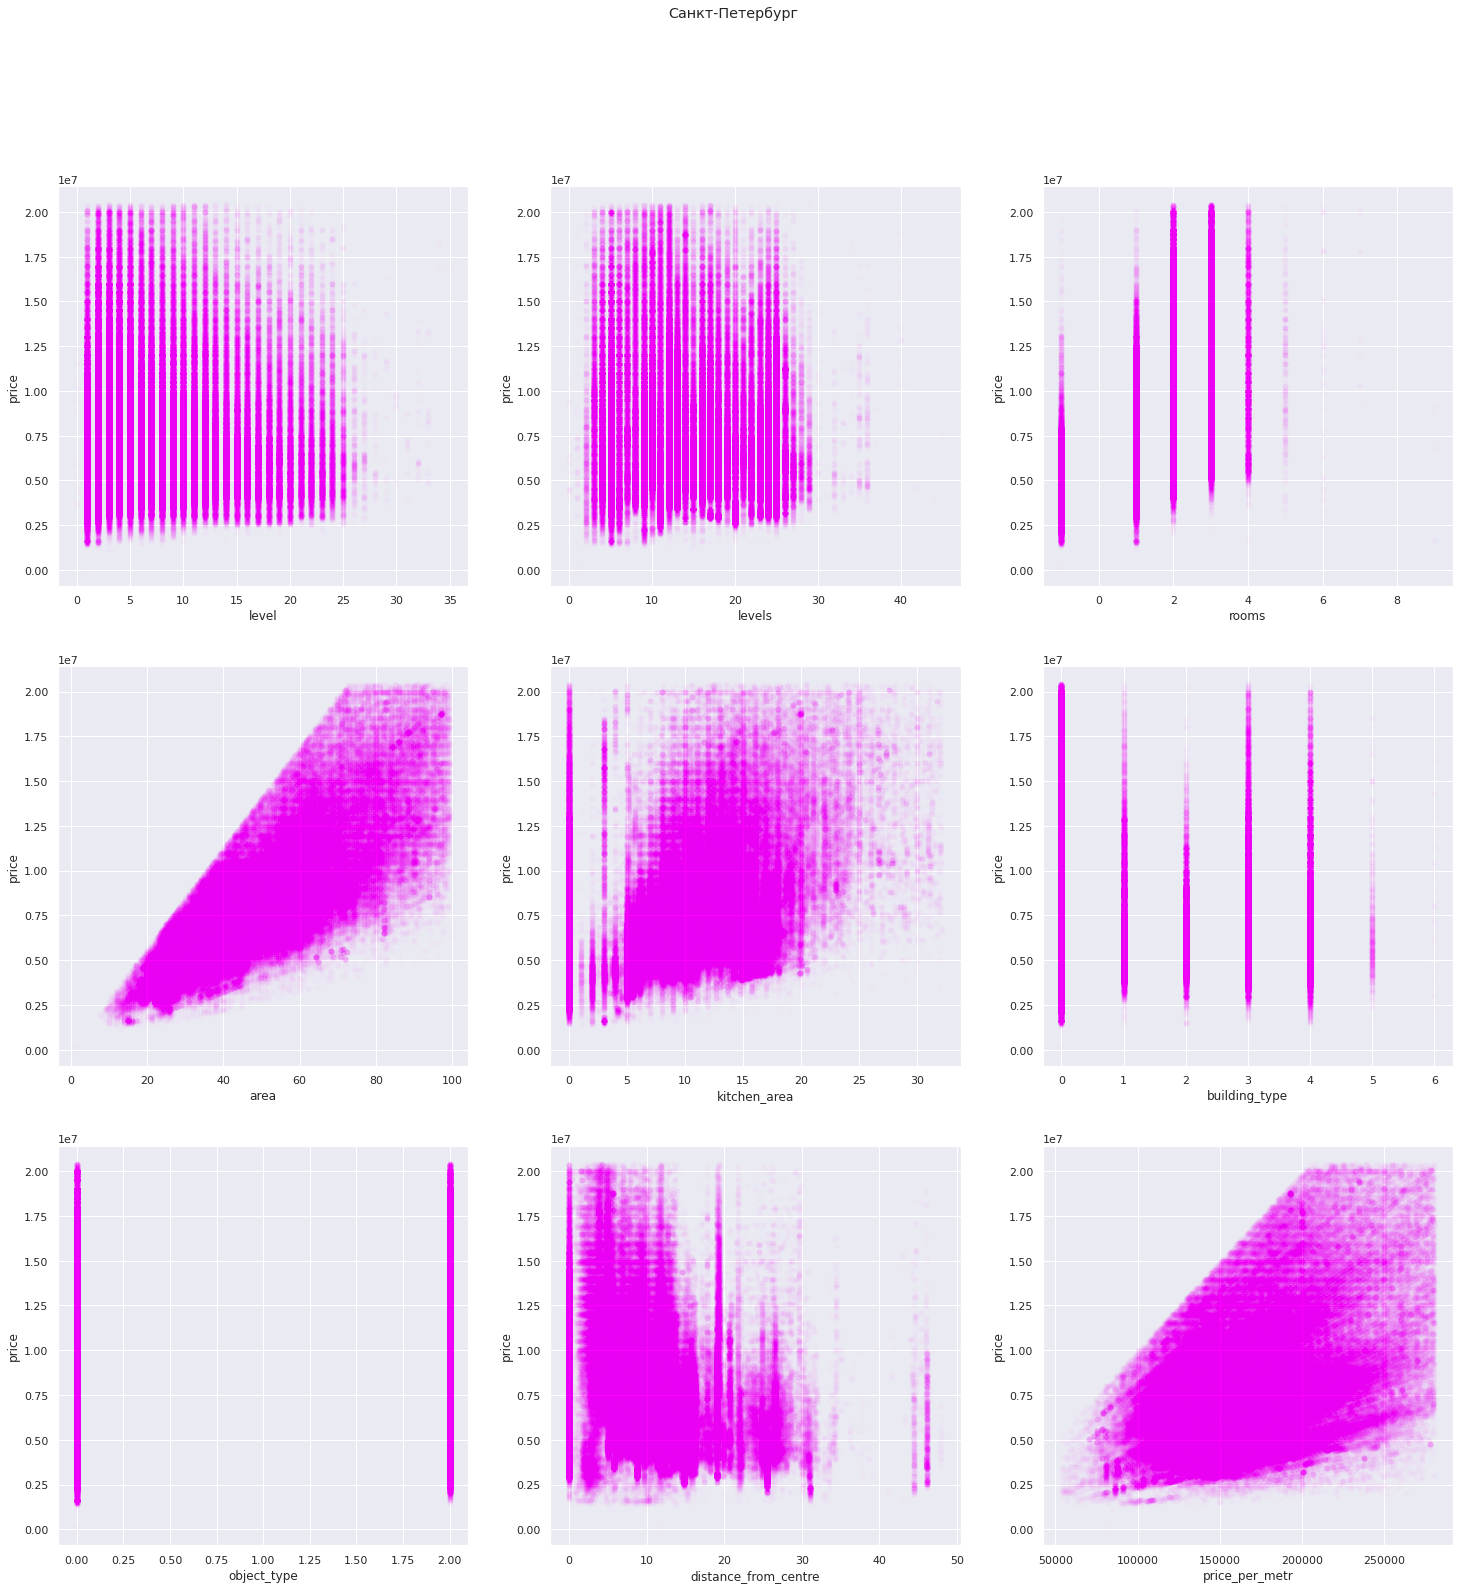

In [17]:
fig, axes = plt.subplots(3, 3, figsize = (25, 25))
sns.set()
fig.suptitle('Санкт-Петербург')

sns.scatterplot(x='level', y='price', data=spb_df, ax = axes[0, 0], alpha = 0.01 , color=(1, 0, 1, 1))

sns.scatterplot(x='levels', y='price', data=spb_df, ax = axes[0, 1], alpha = 0.01 , color=(1, 0, 1, 1))

sns.scatterplot(x='rooms', y='price', data=spb_df, ax = axes[0, 2], alpha = 0.01, color=(1, 0, 1, 1))

sns.scatterplot(x='area', y='price', data=spb_df, ax = axes[1, 0], alpha = 0.01, color=(1, 0, 1, 1))

sns.scatterplot(x='kitchen_area', y='price', data=spb_df, ax = axes[1, 1], alpha = 0.01, color=(1, 0, 1, 1))

sns.scatterplot(x='building_type', y='price', data=spb_df, ax = axes[1, 2], alpha = 0.01, color=(1, 0, 1, 1))

sns.scatterplot(x='object_type', y='price', data=spb_df, ax = axes[2, 0], alpha = 0.01, color=(1, 0, 1, 1))

sns.scatterplot(x='distance_from_centre', y='price', data=spb_df, ax = axes[2, 1], alpha = 0.01, color=(1, 0, 1, 1))

sns.scatterplot(x='price_per_metr', y='price', data=spb_df, ax = axes[2, 2], alpha = 0.01, color=(1, 0, 1, 1))

<AxesSubplot:>

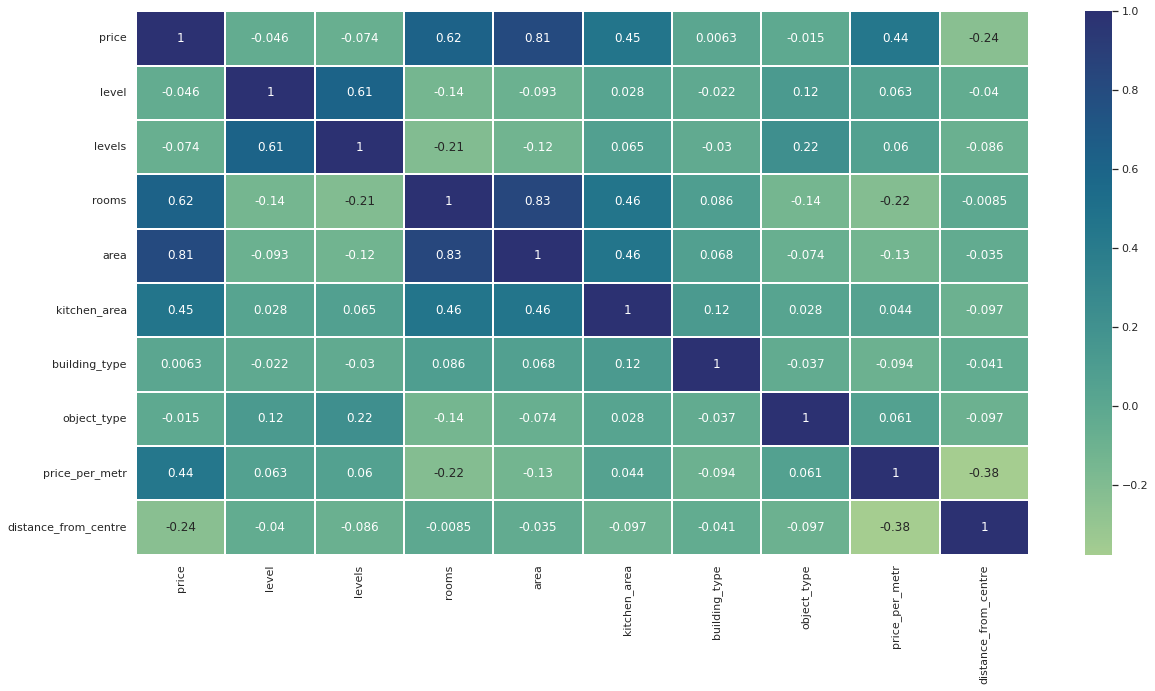

In [18]:
corr = spb_df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, cmap='crest', linewidth=0.2, annot=True)

In [19]:
X = spb_df.drop(columns=['price', 'price_per_metr'])
y = spb_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [20]:
pipe = make_pipeline(StandardScaler(), LinearRegression())

In [21]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [22]:
mae = mean_absolute_error(y_test, pipe.predict(X_test))
spb_pred = pipe.predict(X_test)
r_spb = r2_score(y_test, spb_pred)
print("коэффициент-R^2: ", r_spb)
print("средняя абсолютная ошибка: ", mae)

коэффициент-R^2:  0.7241921014342202
средняя абсолютная ошибка:  1335308.6711527589


In [23]:
X = spb_df.drop(columns=['price', 'price_per_metr'])
y = spb_df['price_per_metr']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

pipe = make_pipeline(StandardScaler(), LinearRegression())
pipe.fit(X_train, y_train)

mae = mean_absolute_error(y_test, pipe.predict(X_test))
spb_pred = pipe.predict(X_test)
r_spb = r2_score(y_test, spb_pred)
print("R^2: ", r_spb)
print("Avg abs error: ", mae * 11," rub")

R^2:  0.22544960606106368
Avg abs error:  300407.18346691737  rub
